In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

se = pl.read_parquet('../data/processed_with_signal_info/core_stop_events.parquet')
print(f'Total stop events: {len(se):,}')
print(f'Columns: {se.columns}')

Total stop events: 950,896
Columns: ['fzg_id', 'drop_row_idx', 'arrival_time', 'departure_time', 'linie', 'fahrt_id', 'ort_nr_start', 'stop_index', 'stop_status', 'scheduled_arrival_time', 'delay_calculated_sec', 'delay_recorded_sec', 'dwell_time', 'travel_time', 'besetztgrad', 'is_peak_hour', 'is_workday', 'has_traffic_signal']


## Step 1 — Stop status 分布

=== Stop status 整体分布 ===
shape: (3, 3)
┌─────────────┬────────┬───────┐
│ stop_status ┆ count  ┆ pct   │
│ ---         ┆ ---    ┆ ---   │
│ str         ┆ u32    ┆ f64   │
╞═════════════╪════════╪═══════╡
│ normal      ┆ 763947 ┆ 80.34 │
│ no_door     ┆ 186250 ┆ 19.59 │
│ multi_door  ┆ 699    ┆ 0.07  │
└─────────────┴────────┴───────┘


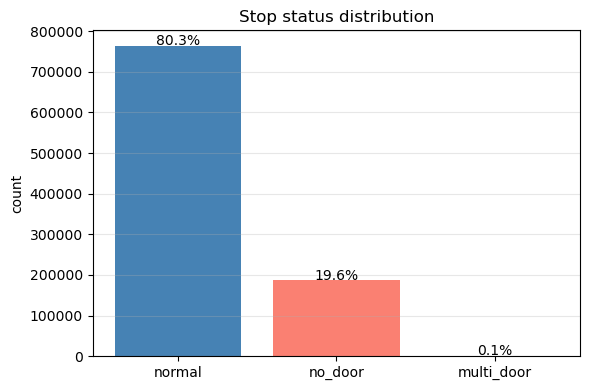

In [3]:
status_dist = (
    se.group_by('stop_status')
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / len(se) * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print('=== Stop status 整体分布 ===')
print(status_dist)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'normal': 'steelblue', 'no_door': 'salmon', 'multi_door': 'mediumseagreen'}
labels = status_dist['stop_status'].to_list()
counts = status_dist['count'].to_list()
ax.bar(labels, counts, color=[colors.get(l, 'gray') for l in labels])
for i, (l, c) in enumerate(zip(labels, counts)):
    ax.text(i, c + 2000, f'{c/len(se)*100:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('count')
ax.set_title('Stop status distribution')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 — Dwell time 分布（normal + multi_door）

In [4]:
with_door = se.filter(pl.col('stop_status') != 'no_door')
total_with_door = len(with_door)

n_negative = (with_door['dwell_time'] < 0).sum()
n_zero     = (with_door['dwell_time'] == 0).sum()
n_positive = (with_door['dwell_time'] > 0).sum()

print(f'normal + multi_door 总计: {total_with_door:,}')
print()
print(f'dwell_time < 0  : {n_negative:>8,}  ({n_negative/total_with_door*100:.2f}%)')
print(f'dwell_time == 0 : {n_zero:>8,}  ({n_zero/total_with_door*100:.2f}%)  ← rescue 后残余（真实数据缺失）')
print(f'dwell_time > 0  : {n_positive:>8,}  ({n_positive/total_with_door*100:.2f}%)  ← 可信')
print()

pos = with_door.filter(pl.col('dwell_time') > 0)['dwell_time'].to_numpy()
print('=== dwell_time > 0 的分布（秒）===')
for p in [5, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p:<3d}: {np.percentile(pos, p):>7.1f} s')
print(f'  mean: {pos.mean():>7.1f} s')

normal + multi_door 总计: 764,646

dwell_time < 0  :        0  (0.00%)
dwell_time == 0 :   58,034  (7.59%)  ← rescue 后残余（真实数据缺失）
dwell_time > 0  :  706,612  (92.41%)  ← 可信

=== dwell_time > 0 的分布（秒）===
  p5  :    11.0 s
  p25 :    16.0 s
  p50 :    20.0 s
  p75 :    28.0 s
  p90 :    49.0 s
  p95 :    73.0 s
  p99 :   581.9 s
  mean:    44.9 s


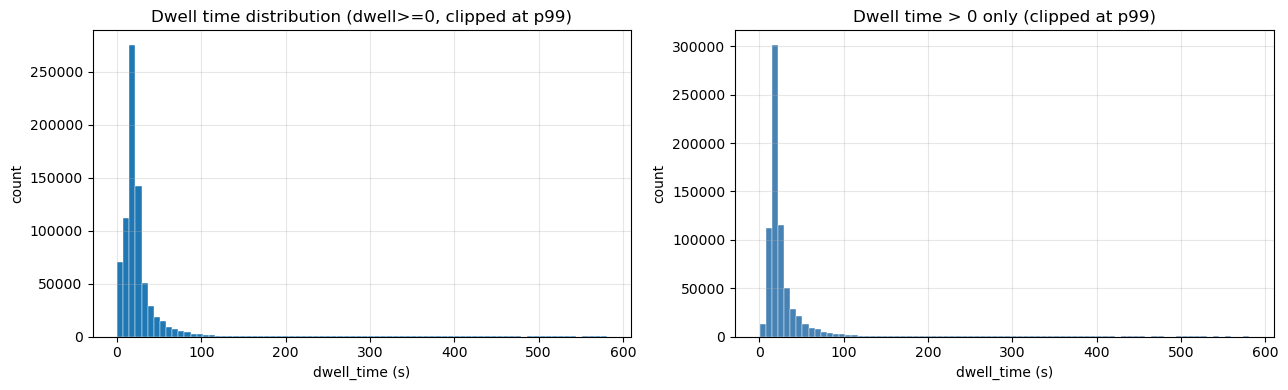

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：dwell_time 分布概览（含 0）
dt_vals = with_door['dwell_time'].to_numpy().astype(float)
clip = np.percentile(dt_vals[dt_vals > 0], 99)
plot_vals = dt_vals[(dt_vals >= 0) & (dt_vals <= clip)]
axes[0].hist(plot_vals, bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('dwell_time (s)')
axes[0].set_ylabel('count')
axes[0].set_title('Dwell time distribution (dwell>=0, clipped at p99)')
axes[0].grid(alpha=0.3)

# 右：仅 dwell_time > 0
clip2 = np.percentile(pos, 99)
axes[1].hist(pos[pos <= clip2], bins=80, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].set_xlabel('dwell_time (s)')
axes[1].set_ylabel('count')
axes[1].set_title('Dwell time > 0 only (clipped at p99)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3 — 按路线看 dwell_time=0 比例

In [6]:
linie_dwell = (
    with_door
    .group_by('linie')
    .agg([
        pl.len().alias('total'),
        (pl.col('dwell_time') == 0).sum().alias('n_zero'),
        (pl.col('dwell_time') > 0).sum().alias('n_positive'),
        pl.col('dwell_time').filter(pl.col('dwell_time') > 0).median().alias('median_pos'),
    ])
    .with_columns(
        (pl.col('n_zero') / pl.col('total') * 100).round(1).alias('pct_zero')
    )
    .sort('pct_zero', descending=True)
)

print('=== 各路线 dwell_time=0 比例 ===')
print(linie_dwell.to_pandas().to_string(index=False))

=== 各路线 dwell_time=0 比例 ===
 linie  total  n_zero  n_positive  median_pos  pct_zero
    77   5029    1147        3882   18.012747      22.8
    84   2264     407        1857   14.019261      18.0
    74   1358     222        1136   28.005100      16.3
    78   5220     811        4409   16.995583      15.5
    88   3324     464        2860   17.039715      14.0
    72   3316     440        2876   16.999419      13.3
    81   2847     375        2472   18.004861      13.2
    79   1510     198        1312   15.985806      13.1
   166   2387     309        2078   15.019922      12.9
    47   5244     666        4578   20.003490      12.7
    87   7594     875        6719   17.017289      11.5
    68  33113    3713       29400   19.044366      11.2
    73   1670     183        1487   18.028757      11.0
   104  13199    1343       11856   19.005463      10.2
   108   6796     676        6120   23.009575       9.9
   112   4971     482        4489   20.975191       9.7
    80  17733    172

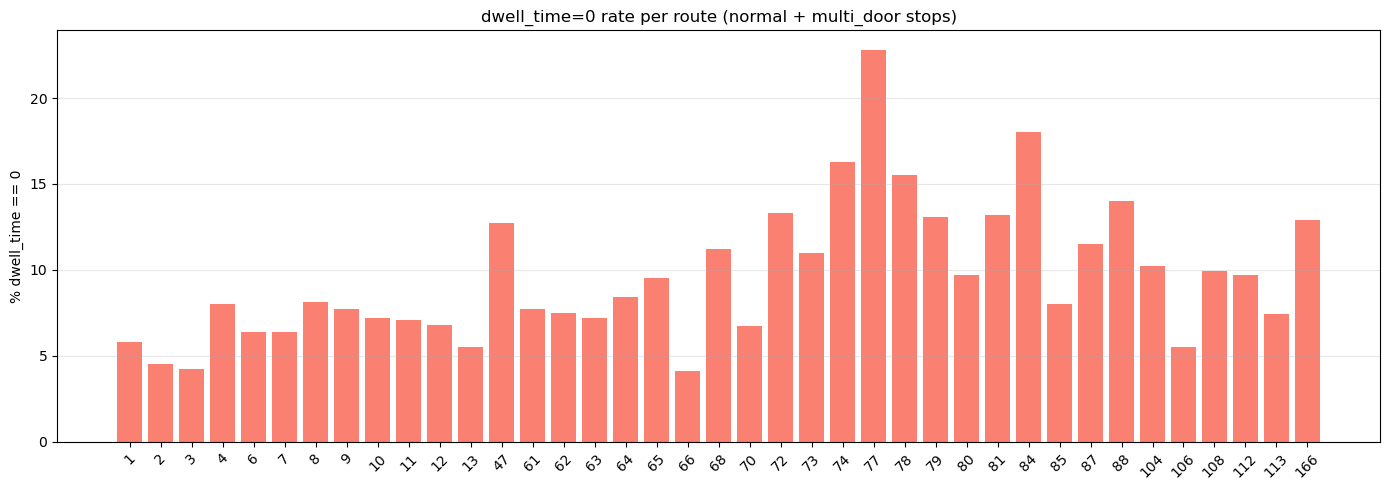

In [7]:
df_plot = linie_dwell.sort('linie').to_pandas()

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_plot))
ax.bar(x, df_plot['pct_zero'], color='salmon', label='dwell=0 (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['linie'].astype(str), rotation=45)
ax.set_ylabel('% dwell_time == 0')
ax.set_title('dwell_time=0 rate per route (normal + multi_door stops)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — 残余 dwell=0 分析

rescue 层已对 186,808 条 dwell=0 事件做了扩展搜索，修复了 142,390 条（76%）。
剩余 64,037 条（6.4%）在 `(prev_drop_idx, next_drop_idx)` 整个范围内仍找不到完整门事件，属于真实数据缺失。

对残余事件再次拆解原因：
- **Case 1**：arrival ≠ drop_time（找到了开门），但整个两站间隔内没有关门
- **Case 2**：arrival == drop_time（连开门都没找到），整个两站间隔内门始终关闭

In [8]:
RAW = '../data/regular_linie_week.csv'

raw_ts = (
    pl.read_csv(RAW, columns=['tst_iso', 'fzg_id'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns(pl.int_range(pl.len()).over('fzg_id').alias('row_idx'))
    .rename({'tst_iso': 'drop_time'})
)

dwell0 = (
    with_door
    .filter(pl.col('dwell_time') == 0)
    .join(
        raw_ts.select(['fzg_id', 'row_idx', 'drop_time']),
        left_on  = ['fzg_id', 'drop_row_idx'],
        right_on = ['fzg_id', 'row_idx'],
        how      = 'left',
    )
    .with_columns(
        pl.when(pl.col('arrival_time') == pl.col('drop_time'))
          .then(pl.lit('Case2: 未找到开门 (arrival=drop_time)'))
          .otherwise(pl.lit('Case1: 找到开门但未找到关门'))
          .alias('zero_reason')
    )
)

reason_dist = (
    dwell0.group_by('zero_reason')
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / len(dwell0) * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print(f'dwell=0 总计: {len(dwell0):,}')
print()
print(reason_dist)

dwell=0 总计: 58,034

shape: (2, 3)
┌─────────────────────────────────┬───────┬───────┐
│ zero_reason                     ┆ count ┆ pct   │
│ ---                             ┆ ---   ┆ ---   │
│ str                             ┆ u32   ┆ f64   │
╞═════════════════════════════════╪═══════╪═══════╡
│ Case1: 找到开门但未找到关门     ┆ 41337 ┆ 71.23 │
│ Case2: 未找到开门               ┆ 16697 ┆ 28.77 │
│ (arrival=drop_tim…              ┆       ┆       │
└─────────────────────────────────┴───────┴───────┘


In [9]:
no_door = se.filter(pl.col('stop_status') == 'no_door')
print('=== no_door sentinel 验证 ===')
print(f'no_door dwell_time 唯一值: {no_door["dwell_time"].unique().to_list()}')
print()

total      = len(se)
n_no_door  = len(no_door)
n_dwell0   = int(n_zero)
n_reliable = int(n_positive)

print('=== 最终问题规模（当前）===')
print(f'总 stop events            : {total:>8,}   100%')
print(f'dwell > 0（可信）         : {n_reliable:>8,}  {n_reliable/total*100:.1f}%')
print(f'no_door（dwell=-1 哨兵）  : {n_no_door:>8,}  {n_no_door/total*100:.1f}%  无门事件，不可计算')
print(f'dwell = 0（残余，数据缺失）: {n_dwell0:>8,}  {n_dwell0/total*100:.1f}%  建议建模时过滤')
print()
print('=== 四阶段对比 ===')
print(f'{"阶段":<28} {"dwell>0":>8} {"dwell=0":>8} {"no_door":>8}')
print('-' * 56)
print(f'{"旧代码（修复前）":<25} {"27.8%":>8} {"53.8%":>8} {"17.5%":>8}')
print(f'{"detector arrival/departure 修复":<22} {"65.6%":>8} {"16.9%":>8} {"17.5%":>8}')
print(f'{"+ rescue 补救层":<25} {"75.8%":>8} {"6.4%":>8} {"17.8%":>8}')
print(f'{"+ 窗口边界裁剪（当前）":<23} {f"{n_reliable/total*100:.1f}%":>8} {f"{n_dwell0/total*100:.1f}%":>8} {f"{n_no_door/total*100:.1f}%":>8}')

=== no_door sentinel 验证 ===
no_door dwell_time 唯一值: [-1.0]

=== 最终问题规模（当前）===
总 stop events            :  950,896   100%
dwell > 0（可信）         :  706,612  74.3%
no_door（dwell=-1 哨兵）  :  186,250  19.6%  无门事件，不可计算
dwell = 0（残余，数据缺失）:   58,034  6.1%  建议建模时过滤

=== 四阶段对比 ===
阶段                            dwell>0  dwell=0  no_door
--------------------------------------------------------
旧代码（修复前）                     27.8%    53.8%    17.5%
detector arrival/departure 修复    65.6%    16.9%    17.5%
+ rescue 补救层                 75.8%     6.4%    17.8%
+ 窗口边界裁剪（当前）               74.3%     6.1%    19.6%


## Step 6 — 残余 dwell=0 示例（5 条）

展示 rescue 后仍为 dwell=0 的 normal/multi_door 停站，附 prev_drop 到 next_drop 之间的完整原始数据，便于逐行检查门信号。

In [10]:
RAW = '../data/regular_linie_week.csv'

raw_full = (
    pl.read_csv(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns([
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx'),
        pl.col('distanz').diff().over('fzg_id').alias('delta'),
    ])
)

samples = (
    se.filter(
        (pl.col('stop_status') != 'no_door') &
        (pl.col('dwell_time') == 0)
    )
    .sample(5, seed=42)
)

# prev/next drop 基于 parquet（仅匹配的停站）
se_sorted = se.sort(['fzg_id', 'drop_row_idx'])

for row in samples.iter_rows(named=True):
    vid      = row['fzg_id']
    drop_idx = row['drop_row_idx']

    vdrops   = se_sorted.filter(pl.col('fzg_id') == vid)['drop_row_idx'].to_list()
    pos      = vdrops.index(drop_idx)
    prev_drop = vdrops[pos - 1] if pos > 0          else None
    next_drop = vdrops[pos + 1] if pos < len(vdrops) - 1 else None

    lo = prev_drop if prev_drop is not None else max(0, drop_idx - 15)
    hi = next_drop if next_drop is not None else drop_idx + 15

    win = (
        raw_full.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(lo, hi))
        .sort('row_idx')
    )

    print('fzg=%-6d  drop=%-6d  linie=%-4d  status=%s' % (vid, drop_idx, row['linie'], row['stop_status']))
    print('  prev_drop=%-6s  next_drop=%-6s' % (prev_drop, next_drop))
    print('  arrival_time=%s' % row['arrival_time'])
    print('  %8s  %8s  %8s  %5s  note' % ('row_idx', 'distanz', 'delta', 'door'))
    for r in win.iter_rows(named=True):
        note = ''
        if r['row_idx'] == drop_idx:   note = '<-- DROP'
        if r['row_idx'] == prev_drop:  note = '<-- prev drop'
        if r['row_idx'] == next_drop:  note = '<-- next drop'
        print('  %8d  %8s  %8s  %5s  %s' % (
            r['row_idx'], str(r['distanz']), str(r['delta']),
            str(r['tuerkriterium']), note
        ))
    print()

fzg=2180    drop=14617   linie=113   status=normal
  prev_drop=14606   next_drop=14661 
  arrival_time=2025-07-30 12:41:36.319440+00:00
   row_idx   distanz     delta   door  note
     14606        60      -291  False  <-- prev drop
     14607        60         0  False  
     14608       189       129  False  
     14609       190         1  False  
     14610       238        48  False  
     14611       253        15  False  
     14612       253         0  False  
     14613       299        46  False  
     14614       359        60  False  
     14615       383        24  False  
     14616       410        27  False  
     14617         0      -410   True  <-- DROP
     14618         0         0   True  
     14619       445       445   True  
     14620       445         0   True  
     14621         0      -445   True  
     14622         0         0   True  
     14623         0         0   True  
     14624         0         0   True  
     14625         0         0   True  

## Step 7 — dwell=-1（no_door）示例（5 条）

展示 no_door 停站在 prev_drop 到 next_drop 之间的原始门信号，确认确实无门事件。

In [11]:
samples_nodoor = (
    se.filter(pl.col('dwell_time') == -1)
    .sample(5, seed=7)
)

for row in samples_nodoor.iter_rows(named=True):
    vid      = row['fzg_id']
    drop_idx = row['drop_row_idx']

    vdrops    = se_sorted.filter(pl.col('fzg_id') == vid)['drop_row_idx'].to_list()
    pos       = vdrops.index(drop_idx)
    prev_drop = vdrops[pos - 1] if pos > 0              else None
    next_drop = vdrops[pos + 1] if pos < len(vdrops) - 1 else None

    lo = prev_drop if prev_drop is not None else max(0, drop_idx - 15)
    hi = next_drop if next_drop is not None else drop_idx + 15

    win = (
        raw_full.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(lo, hi))
        .sort('row_idx')
    )

    print('fzg=%-6d  drop=%-6d  linie=%-4d  status=%s  dwell=%s' % (
        vid, drop_idx, row['linie'], row['stop_status'], row['dwell_time']))
    print('  prev_drop=%-6s  next_drop=%-6s' % (prev_drop, next_drop))
    print('  %8s  %8s  %8s  %5s  note' % ('row_idx', 'distanz', 'delta', 'door'))
    for r in win.iter_rows(named=True):
        note = ''
        if r['row_idx'] == drop_idx:   note = '<-- DROP'
        if r['row_idx'] == prev_drop:  note = '<-- prev drop'
        if r['row_idx'] == next_drop:  note = '<-- next drop'
        print('  %8d  %8s  %8s  %5s  %s' % (
            r['row_idx'], str(r['distanz']), str(r['delta']),
            str(r['tuerkriterium']), note
        ))
    print()

fzg=807     drop=5018    linie=7     status=no_door  dwell=-1.0
  prev_drop=5011    next_drop=5026  
   row_idx   distanz     delta   door  note
      5011       539        39   True  <-- prev drop
      5012        20      -519  False  
      5013       196       176  False  
      5014       383       187  False  
      5015       498       115  False  
      5016       498         0   True  
      5017       528        30   True  
      5018        15      -513  False  <-- DROP
      5019        15         0  False  
      5020       132       117  False  
      5021       182        50  False  
      5022       220        38  False  
      5023       269        49  False  
      5024       368        99  False  
      5025       368         0  False  
      5026       495       127  False  <-- next drop

fzg=1152    drop=7760    linie=61    status=no_door  dwell=-1.0
  prev_drop=7756    next_drop=7764  
   row_idx   distanz     delta   door  note
      7756       184       169  Fal